In [1]:
# Cell 1 — Dataset Path Check
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print(os.listdir('/kaggle/input/datasets/andrewmvd'))
print(os.listdir('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k'))

['ocular-disease-recognition-odir5k']
['preprocessed_images', 'ODIR-5K', 'full_df.csv']


In [2]:
# Cell 2 — Load CSV
BASE_PATH = '/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k'
IMG_DIR   = f'{BASE_PATH}/preprocessed_images'

df = pd.read_csv(f'{BASE_PATH}/full_df.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (6392, 19)
Columns: ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'filepath', 'labels', 'target', 'filename']


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


In [3]:
# Cell 3 — Class Distribution
import ast

DISEASE_NAMES = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract',
                 'AMD', 'Hypertensive Retinopathy', 'Myopia', 'Other']
DISEASE_MAP   = {'N': 0, 'D': 1, 'G': 2, 'C': 3, 'A': 4, 'H': 5, 'M': 6, 'O': 7}

df['label_encoded'] = df['labels'].apply(lambda x: DISEASE_MAP[ast.literal_eval(x)[0]])

print("Class Distribution:")
for i, name in enumerate(DISEASE_NAMES):
    count = (df['label_encoded'] == i).sum()
    bar   = '█' * (count // 50)
    print(f"  {name:<28} {count:4d}  {bar}")

Class Distribution:
  Normal                       2873  █████████████████████████████████████████████████████████
  Diabetic Retinopathy         1608  ████████████████████████████████
  Glaucoma                      284  █████
  Cataract                      293  █████
  AMD                           266  █████
  Hypertensive Retinopathy      128  ██
  Myopia                        232  ████
  Other                         708  ██████████████


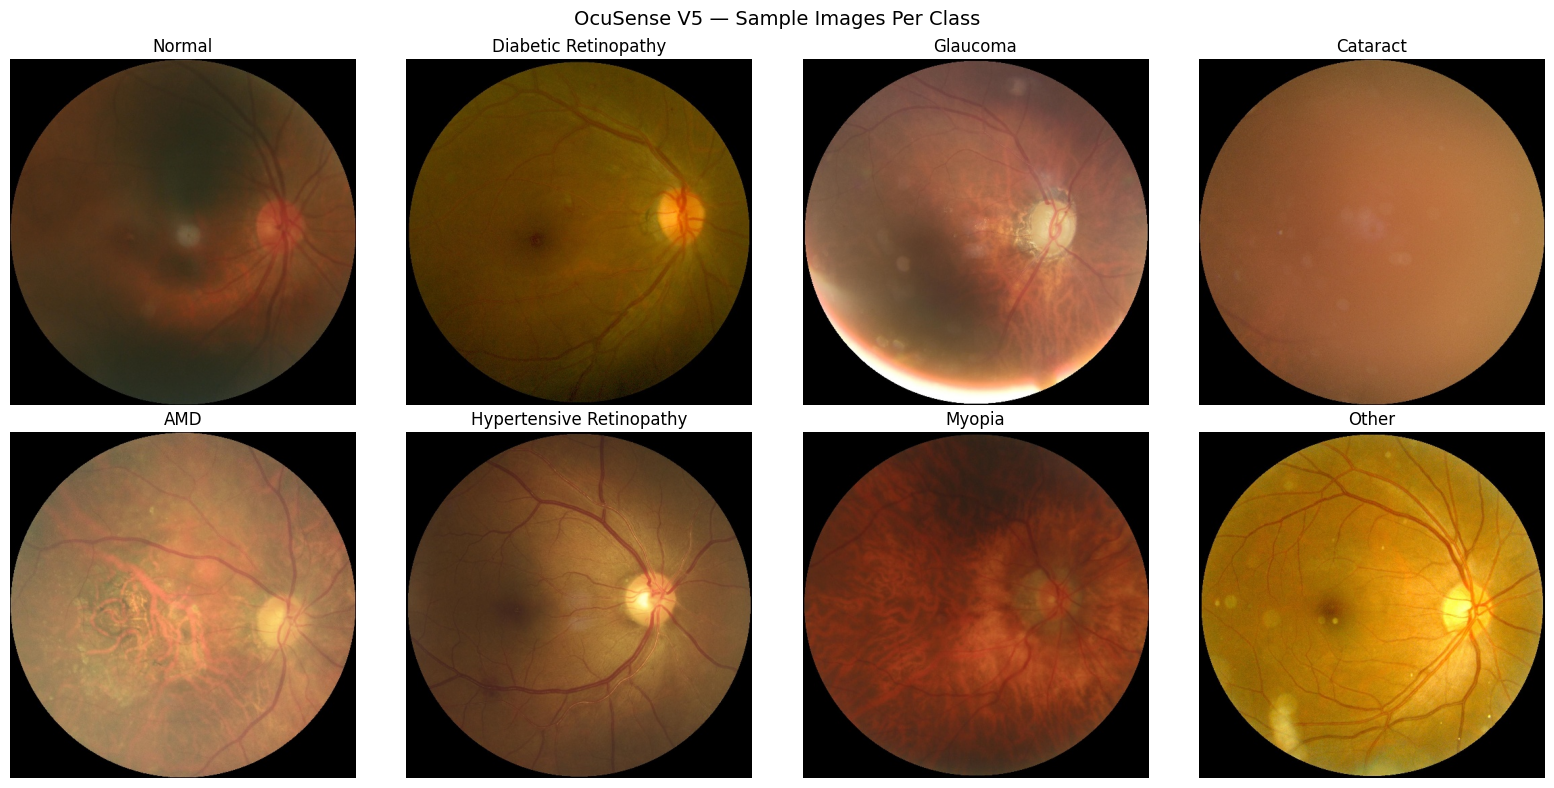

In [4]:
# Cell 4 — Visualize Sample Images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

label_codes = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
df['label_str'] = df['labels'].apply(lambda x: ast.literal_eval(x)[0])

for i, (code, name) in enumerate(zip(label_codes, DISEASE_NAMES)):
    sample   = df[df['label_str'] == code].iloc[0]
    img_path = f"{IMG_DIR}/{sample['filename']}"
    img      = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(name)
    axes[i].axis('off')

plt.suptitle('OcuSense V5 — Sample Images Per Class', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Cell 5 — Imports & Device Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import zipfile
import copy
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [6]:
# Cell 6 — Patient Level Split with Leakage Check
unique_patients = df['ID'].unique()
print(f"Total unique patients : {len(unique_patients)}")
print(f"Total rows            : {len(df)}")

# Split by patient ID to prevent leakage
train_ids, temp_ids = train_test_split(unique_patients, test_size=0.30, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids,        test_size=0.50, random_state=42)

train_df = df[df['ID'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['ID'].isin(val_ids)].reset_index(drop=True)
test_df  = df[df['ID'].isin(test_ids)].reset_index(drop=True)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Leakage verification
train_set = set(train_df['ID'])
val_set   = set(val_df['ID'])
test_set  = set(test_df['ID'])
print(f"\nLeakage Check:")
print(f"  Train ∩ Val  : {len(train_set & val_set)}  ← must be 0")
print(f"  Train ∩ Test : {len(train_set & test_set)} ← must be 0")
print(f"  Val ∩ Test   : {len(val_set & test_set)}   ← must be 0")

print(f"\nTrain class distribution:")
for i, name in enumerate(DISEASE_NAMES):
    count = (train_df['label_encoded'] == i).sum()
    print(f"  {name:<28} {count}")

Total unique patients : 3358
Total rows            : 6392

Train: 4473 | Val: 959 | Test: 960

Leakage Check:
  Train ∩ Val  : 0  ← must be 0
  Train ∩ Test : 0 ← must be 0
  Val ∩ Test   : 0   ← must be 0

Train class distribution:
  Normal                       2041
  Diabetic Retinopathy         1108
  Glaucoma                     180
  Cataract                     191
  AMD                          199
  Hypertensive Retinopathy     102
  Myopia                       172
  Other                        480


In [7]:
# Cell 7 — Loss Function (Weighted CrossEntropy + Label Smoothing)
# Focal Loss was causing instability, reverting to proven weighted CE
print("Using Weighted CrossEntropyLoss with label smoothing")
print("This is what gave us 61.69% in V3 — reliable and stable")

Using Weighted CrossEntropyLoss with label smoothing
This is what gave us 61.69% in V3 — reliable and stable


In [8]:
# Cell 8 — Transforms & Minority Class Augmentation

# Standard train transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Stronger augmentation for minority classes
# (Hypertensive Retinopathy, AMD, Glaucoma, Myopia, Cataract)
minority_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Inference transforms — no augmentation
inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Minority classes: Glaucoma(2), Cataract(3), AMD(4), Hypertensive(5), Myopia(6)
MINORITY_CLASSES = {2, 3, 4, 5, 6}

print("Transforms defined!")

Transforms defined!


In [9]:
# Cell 9 — Dataset Class
class ODIRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None,
                 minority_transform=None, minority_classes=None):
        self.df                = dataframe
        self.img_dir           = img_dir
        self.transform         = transform
        self.minority_transform = minority_transform
        self.minority_classes  = minority_classes or set()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image    = Image.open(img_path).convert('RGB')
        label    = row['label_encoded']

        # Use stronger augmentation for minority classes during training
        if self.minority_transform and label in self.minority_classes:
            image = self.minority_transform(image)
        elif self.transform:
            image = self.transform(image)

        return image, label

train_dataset = ODIRDataset(train_df, IMG_DIR,
                             transform=train_transforms,
                             minority_transform=minority_transforms,
                             minority_classes=MINORITY_CLASSES)
val_dataset   = ODIRDataset(val_df,   IMG_DIR, transform=inference_transforms)
test_dataset  = ODIRDataset(test_df,  IMG_DIR, transform=inference_transforms)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 4473 | Val: 959 | Test: 960


In [10]:
# Cell 10 — Weighted Sampler & Dataloaders

# Class weights for loss
class_counts         = train_df['label_encoded'].value_counts().sort_index().values
class_weights        = 1.0 / class_counts
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# Capped weighted sampler — prevents over-amplification of rare classes
# Cap max weight at 5x the minimum weight
min_weight    = class_weights.min()
capped_weights = np.clip(class_weights, 0, min_weight * 5)
sample_weights = [capped_weights[l] for l in train_df['label_encoded']]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches | Test: {len(test_loader)} batches")
print(f"\nClass weights for loss:")
for name, w in zip(DISEASE_NAMES, class_weights):
    print(f"  {name:<28} {w:.4f}")

Train: 140 batches | Val: 30 batches | Test: 30 batches

Class weights for loss:
  Normal                       0.0005
  Diabetic Retinopathy         0.0009
  Glaucoma                     0.0056
  Cataract                     0.0052
  AMD                          0.0050
  Hypertensive Retinopathy     0.0098
  Myopia                       0.0058
  Other                        0.0021


In [11]:
# Cell 11 — OcuSense V5 Model Architecture
class OcuSenseV5(nn.Module):
    """
    EfficientNet-B3 backbone with stronger classifier head.
    GAP -> Dropout(0.4) -> Linear(512) -> ReLU -> Dropout(0.2) -> Linear(8)
    """
    def __init__(self, num_classes=8):
        super(OcuSenseV5, self).__init__()
        self.backbone   = models.efficientnet_b3(weights='IMAGENET1K_V1')
        in_features     = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model     = OcuSenseV5(num_classes=8).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

print(f"Model ready! Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model ready! Parameters: 11,487,280


In [12]:
# Cell 12 — Early Stopping
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience  = patience
        self.counter   = 0
        self.best_acc  = 0
        self.stop      = False

    def __call__(self, val_acc):
        if val_acc > self.best_acc:
            self.best_acc = val_acc
            self.counter  = 0
        else:
            self.counter += 1
            print(f"  EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True

early_stop = EarlyStopping(patience=10)
print("Early stopping ready — patience 10 on Val Acc!")

Early stopping ready — patience 10 on Val Acc!


In [13]:
# Cell 13 — Training Loop
NUM_EPOCHS    = 30
best_val_acc  = 0.0
best_macro_f1 = 0.0

for epoch in range(NUM_EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item()
        _, predicted   = outputs.max(1)
        train_correct += predicted.eq(labels).sum().item()
        train_total   += labels.size(0)

    train_acc  = 100. * train_correct / train_total
    train_loss = train_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            val_loss      += loss.item()
            _, predicted   = outputs.max(1)
            val_correct   += predicted.eq(labels).sum().item()
            val_total     += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc     = 100. * val_correct / val_total
    val_loss    = val_loss / len(val_loader)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    macro_f1    = f1_score(all_labels, all_preds, average='macro')

    scheduler.step()

    # Save best model based on val acc
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_macro_f1 = macro_f1
        torch.save(model.state_dict(), '/kaggle/working/ocusense_v5_best.pth')
        print(f"  ★ Best saved! Val Acc: {val_acc:.2f}% | Macro F1: {macro_f1:.4f}")

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Weighted F1: {weighted_f1:.4f} | Macro F1: {macro_f1:.4f}")

    early_stop(val_acc)
    if early_stop.stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

print(f"\nV5 Training Complete!")
print(f"Best Val Acc  : {best_val_acc:.2f}%")
print(f"Best Macro F1 : {best_macro_f1:.4f}")

  ★ Best saved! Val Acc: 17.41% | Macro F1: 0.2160
Epoch [01/30] Train Loss: 1.4177 | Train Acc: 39.21% | Val Loss: 2.8053 | Val Acc: 17.41% | Weighted F1: 0.0930 | Macro F1: 0.2160
  ★ Best saved! Val Acc: 20.13% | Macro F1: 0.1949
Epoch [02/30] Train Loss: 1.0281 | Train Acc: 54.82% | Val Loss: 2.7517 | Val Acc: 20.13% | Weighted F1: 0.1581 | Macro F1: 0.1949
  ★ Best saved! Val Acc: 26.69% | Macro F1: 0.3281
Epoch [03/30] Train Loss: 0.9621 | Train Acc: 58.93% | Val Loss: 2.5646 | Val Acc: 26.69% | Weighted F1: 0.2338 | Macro F1: 0.3281
  ★ Best saved! Val Acc: 29.41% | Macro F1: 0.2644
Epoch [04/30] Train Loss: 0.9171 | Train Acc: 63.49% | Val Loss: 2.7351 | Val Acc: 29.41% | Weighted F1: 0.2452 | Macro F1: 0.2644
Epoch [05/30] Train Loss: 0.8552 | Train Acc: 69.24% | Val Loss: 2.8487 | Val Acc: 27.95% | Weighted F1: 0.2687 | Macro F1: 0.2090
  EarlyStopping: 1/10
  ★ Best saved! Val Acc: 43.27% | Macro F1: 0.3487
Epoch [06/30] Train Loss: 0.8287 | Train Acc: 72.26% | Val Loss: 2.6

Test Accuracy : 57.19%
Macro F1      : 0.3256
Weighted F1   : 0.5520

Classification Report:
                          precision    recall  f1-score   support

                  Normal       0.70      0.65      0.67       444
    Diabetic Retinopathy       0.58      0.68      0.63       240
                Glaucoma       0.50      0.04      0.08        47
                Cataract       1.00      0.12      0.22        48
                     AMD       0.00      0.00      0.00        28
Hypertensive Retinopathy       0.00      0.00      0.00         9
                  Myopia       0.94      0.42      0.58        36
                   Other       0.31      0.69      0.43       108

                accuracy                           0.57       960
               macro avg       0.50      0.33      0.33       960
            weighted avg       0.61      0.57      0.55       960



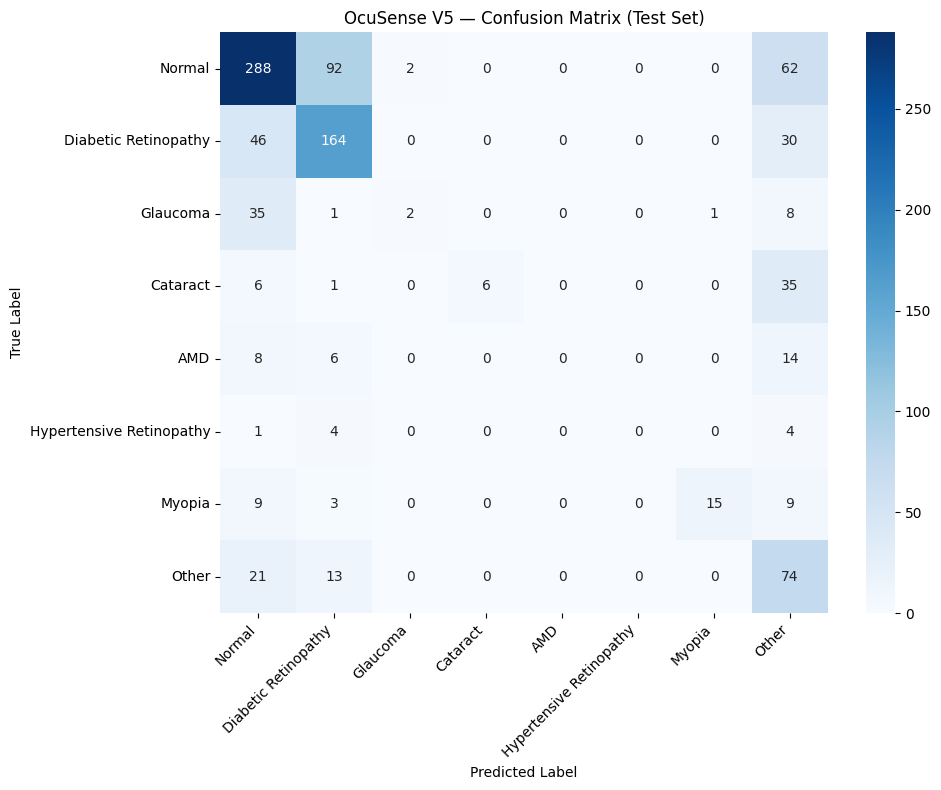

In [14]:
# Cell 14 — Final Evaluation on Unseen Test Set
model.load_state_dict(torch.load('/kaggle/working/ocusense_v5_best.pth'))
model.eval()

test_correct, test_total = 0, 0
all_preds, all_labels    = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = outputs.max(1)
        test_correct  += predicted.eq(labels).sum().item()
        test_total    += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc    = 100. * test_correct / test_total
macro_f1    = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Macro F1      : {macro_f1:.4f}")
print(f"Weighted F1   : {weighted_f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=DISEASE_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DISEASE_NAMES, yticklabels=DISEASE_NAMES)
plt.title('OcuSense V5 — Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/v5_confusion_matrix.png', dpi=150)
plt.show()

In [15]:
# Cell 15 — Save All Results
with zipfile.ZipFile('/kaggle/working/ocusense_v5_results.zip', 'w') as zf:
    zf.write('/kaggle/working/ocusense_v5_best.pth',    'ocusense_v5_best.pth')
    zf.write('/kaggle/working/v5_confusion_matrix.png', 'v5_confusion_matrix.png')

print("V5 results saved! Download: ocusense_v5_results.zip")

V5 results saved! Download: ocusense_v5_results.zip
